# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Muhammad Dafa Alvian Ramadhani
- **Email:** dafaalvian17@gmail.com
- **ID Dicoding:** CDCC284D6Y2233

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset e-commerce yang digunakan, berikut merupakan pertanyaan pertanyaan yang akan dijawab melalui proses analisis data:

1. Produk apa yang memiliki jumlah penjualan tertinggi berdasarkan total quantity yang terjual pada periode Januari 2016 hingga Desember 2018?
2. Bagaimana tren jumlah transaksi bulanan berdasarkan jumlah order dari Januari 2016 hingga Desember 2018?
3. Siapa saja pelanggan dengan jumlah transaksi terbanyak berdasarkan jumlah order pada periode Januari 2016 hingga Desember 2018, dan bagaimana perbandingan tingkat aktivitas transaksi di antara pelanggan tersebut?
4. Kategori produk apa yang memiliki jumlah penjualan tertinggi berdasarkan total item yang terjual pada periode Januari 2016 hingga Desember 2018?

## Import Semua Packages/Library yang Digunakan

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Library

Pda tahapan ini, dilakukan import library yang akan digunakan pada proses analisis data. Librarynya sebagai berikut:
- **Numpy**: Digunakan untuk komputasi numerik
- **Pandas**: Digunakan untuk manipulasi data dan analisis data
- **Matplotlib**: Digunakan untuk visualisasi data
- **Seaborn**: Membuat visualisasi data lebih menarik

## Data Wrangling

### Gathering Data

In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
orders_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/order_items_dataset.csv')
products_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/products_dataset.csv')
customers_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/customers_dataset.csv')

In [86]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [87]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [88]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [89]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Gathering Data**

Pada tahap ini dilakukan proses pengumpulan data dengan memuat beberapa dataset yang akan digunakan dalam analisis. Dataset yang digunakan antara lain:

- orders_dataset.csv
- order_items_dataset.csv
- products_dataset.csv
- customers_dataset.csv

Setiap dataset dimuat ke dalam DataFrame menggunakan library pandas, kemudian ditampilkan lima baris pertama untuk memahami struktur data.

**Insight:**
- Dataset terdiri dari beberapa tabel utama yaitu orders, order_items, products, dan customers.
- Setiap dataset memiliki fungsi yang berbeda, seperti orders untuk informasi transaksi, order_items untuk detail produk yang dibeli, products untuk informasi produk, dan customers untuk informasi pelanggan.
- Data yang dimuat sudah berhasil dibaca ke dalam DataFrame dan siap untuk dilakukan tahap analisis selanjutnya.

### Assessing Data

**Assesing Data**

Pada tahap ini dilakukan pemeriksaan kualitas data untuk memastikan tidak terdapat masalah yang dapat mempengaruhi hasil analisis.

Beberapa hal yang diperiksa antara lain:
- Missing values pada setiap kolom
- Duplikasi data
- Konsistensi tipe data

Hasil dari proses ini digunakan sebagai dasar dalam melakukan data cleaning.

1. Cek info struktur dataset

In [90]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [91]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [92]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [93]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


2. Cek Missing Value

In [94]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [95]:
order_items_df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [96]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [97]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


3. Cek Duplikat Data

In [98]:
orders_df.duplicated().sum()

np.int64(0)

In [99]:
order_items_df.duplicated().sum()

np.int64(0)

In [100]:
products_df.duplicated().sum()

np.int64(0)

In [101]:
customers_df.duplicated().sum()

np.int64(0)

4. Cek Invalid Data



In [102]:
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [103]:
(order_items_df['price']< 0).sum()

np.int64(0)

In [104]:
(order_items_df['order_item_id']< 0).sum()

np.int64(0)

In [105]:
(order_items_df['freight_value']< 0).sum()

np.int64(0)

In [106]:
(products_df['product_name_lenght'] < 0).sum()

np.int64(0)

In [107]:
(products_df['product_description_lenght'] < 0).sum()

np.int64(0)

In [108]:
customers_df['customer_state'].value_counts()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [109]:
customers_df['customer_city'].value_counts().head()

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521


5. descriptive statistic


In [110]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- Berdasarkan hasil pemeriksaan struktur data, ditemukan bahwa beberapa kolom yang berkaitan dengan waktu seperti `order_purchase_timestamp`, `order_approved_at`, dll masih bertipe data object, sehingga perlu dikonversi ke tipe datetime pada tahap cleaning data.

- Ditemukan missing value pada dataset `orders_df`, khususnya pada kolom:
  - `order_approved_at` sebanyak 160 data
  - `order_delivered_carrier_date` sebanyak 1783 data
  - `order_delivered_customer_date` sebanyak 2965 data

- Selain itu, dataset `products_df` memiliki missing value yang cukup signifikan pada beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, dan atribut produk lainnya dengan total sekitar 610 data kosong. Beberapa kolom numerik seperti `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm` juga memiliki missing value dalam jumlah kecil.

- Tidak ditemukan data duplikat pada seluruh dataset yang digunakan.

- Berdasarkan pemeriksaan nilai data, tidak ditemukan nilai yang tidak valid seperti nilai negatif pada kolom numerik maupun kategori yang tidak wajar pada kolom kategorikal.

- Berdasarkan hasil statistik deskriptif pada dataset `order_items_df`, sebagian besar transaksi hanya terdiri dari satu item. Selain itu, terdapat perbedaan yang cukup signifikan antara nilai median dan nilai maksimum pada kolom `price` dan `freight_value`, yang mengindikasikan adanya distribusi data yang skewed serta kemungkinan adanya outlier.

- Secara keseluruhan, dataset memiliki kualitas yang cukup baik, namun memerlukan proses pembersihan data terutama dalam penanganan missing value dan konversi tipe data sebelum dilakukan analisis lebih lanjut.

### Cleaning Data

**Data Cleaning**

Pada tahap ini dilakukan proses pembersihan data berdasarkan hasil dari proses data assessing yang telah dilakukan sebelumnya.

Beberapa langkah yang dilakukan dalam tahap ini meliputi:

- Menangani missing values pada beberapa kolom yang memiliki data kosong
- Menghapus data duplikat untuk memastikan tidak terjadi perhitungan ganda
- Mengubah tipe data pada kolom tertentu, terutama kolom tanggal, agar sesuai dengan format yang dibutuhkan untuk analisis

Tujuan dari tahap ini adalah memastikan bahwa data yang digunakan telah bersih, konsisten, dan siap untuk dianalisis lebih lanjut.

1. konversi format

In [111]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

In [112]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

2. handle missing value

In [113]:
orders_df_clean = orders_df[orders_df['order_status'] == 'delivered']

order_df_clean = orders_df_clean.dropna(subset=['order_delivered_customer_date', 'order_delivered_carrier_date'])

In [114]:
orders_df_clean.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [115]:
orders_df_clean = orders_df_clean.dropna()

In [116]:
orders_df_clean.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


- Meskipun terdapat cukup banyak missing value pada beberapa kolom di dataset orders seperti `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`, data tidak dihapus atau diisi secara langsung karena nilai kosong tersebut hanya terjadi pada kolom tertentu dan tidak mempengaruhi keseluruhan informasi transaksi.

- Nilai kosong tersebut juga berkaitan dengan status pesanan, seperti pesanan yang belum selesai atau dibatalkan, sehingga masih merepresentasikan kondisi nyata dalam data.

- Oleh karena itu, penanganan missing value dilakukan secara kontekstual dengan memfilter data yang relevan, yaitu pesanan dengan status delivered dan memiliki informasi pengiriman yang lengkap.

In [117]:
products_df = products_df.dropna(subset=['product_category_name'])

In [118]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,1
product_length_cm,1
product_height_cm,1
product_width_cm,1


- Setelah dilakukan penghapusan missing value pada kolom `product_category_name`, masih terdapat sejumlah kecil missing value pada beberapa kolom numerik seperti dimensi dan berat produk.

- Namun, karena jumlahnya sangat kecil dan tidak berpengaruh signifikan terhadap analisis yang dilakukan, data tersebut tetap dipertahankan.

**Insight:**
- Data yang berkaitan dengan waktu telah dikonversi ke format datetime sehingga lebih mudah digunakan untuk analisis berbasis waktu.

- Missing value pada dataset orders tidak ditangani secara langsung secara keseluruhan, melainkan difokuskan pada data yang relevan untuk analisis, yaitu pesanan dengan status delivered.

- Setelah dilakukan pembersihan, masih ditemukan sedikit data yang tidak konsisten dan kemudian dihapus karena jumlahnya sangat kecil.

- Pada dataset products, data tanpa kategori produk dihapus karena tidak cukup informatif untuk analisis.

- Meskipun terdapat indikasi outlier pada beberapa kolom numerik seperti `price` dan `freight_value`, data tersebut tidak dihapus karena nilai ekstrem masih memungkinkan terjadi dalam konteks transaksi e-commerce, seperti produk dengan harga tinggi atau biaya pengiriman yang besar.

- Penghapusan outlier tanpa analisis mendalam berpotensi menghilangkan informasi penting yang justru merepresentasikan kondisi nyata dari data.
Oleh karena itu, data tetap dipertahankan agar hasil analisis tetap mencerminkan kondisi sebenarnya.

- Secara keseluruhan, proses cleaning dilakukan secara selektif agar data tetap realistis namun cukup bersih untuk dianalisis.

## Exploratory Data Analysis (EDA)

## Exploratory Data Analysis (EDA)

Pada EDA ini dilakukan eksplorasi data untuk memahami karakteristik dataset sebelum menjawab pertanyaan analisis.

Beberapa aspek yang dieksplorasi meliputi:

1. Distribusi jumlah transaksi berdasarkan produk
2. Distribusi jumlah penjualan berdasarkan kategori produk
3. Distribusi aktivitas transaksi pelanggan
4. Tren transaksi berdasarkan waktu (bulanan)

Eksplorasi ini bertujuan untuk menemukan pola awal dalam data yang akan digunakan sebagai dasar dalam analisis selanjutnya.


In [119]:
# Menggabungkan dataset

orders_items_df = pd.merge(
    orders_df,
    order_items_df,
    on = 'order_id',
    how = 'inner'
)


all_df = pd.merge(
    orders_items_df,
    products_df,
    on = 'product_id',
    how = 'inner'
)

all_df = pd.merge(
    all_df,
    customers_df,
    on = 'customer_id',
    how = 'inner'
)

all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [120]:
all_df.shape

(111047, 26)

In [121]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111047 entries, 0 to 111046
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       111047 non-null  object        
 1   customer_id                    111047 non-null  object        
 2   order_status                   111047 non-null  object        
 3   order_purchase_timestamp       111047 non-null  datetime64[ns]
 4   order_approved_at              111033 non-null  datetime64[ns]
 5   order_delivered_carrier_date   109890 non-null  datetime64[ns]
 6   order_delivered_customer_date  108659 non-null  datetime64[ns]
 7   order_estimated_delivery_date  111047 non-null  datetime64[ns]
 8   order_item_id                  111047 non-null  int64         
 9   product_id                     111047 non-null  object        
 10  seller_id                      111047 non-null  object        
 11  

In [122]:
all_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix
count,111047,111033,109890,108659,111047,111047.000000,111047,111047.000000,111047.000000,111047.000000,111047.000000,111047.000000,111046.000000,111046.000000,111046.000000,111046.000000,111047.000000
mean,2018-01-01 18:36:26.769205504,2018-01-02 06:10:06.729954304,2018-01-05 20:23:33.779215616,2018-01-15 07:23:45.339300096,2018-01-25 14:45:25.181229568,1.198213,2018-01-08 10:05:09.240672768,120.778665,20.025212,48.775978,787.867029,2.209713,2099.979657,30.211003,16.626362,23.041956,35110.181887
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,2016-09-19 00:15:34,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000
25%,2017-09-14 12:10:23,2017-09-14 20:45:12,2017-09-19 15:03:28.750000128,2017-09-27 18:05:01,2017-10-05 00:00:00,1.000000,2017-09-21 04:47:36.500000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,11320.000000
50%,2018-01-21 12:16:51,2018-01-22 14:00:22,2018-01-25 14:11:28,2018-02-05 13:29:43,2018-02-16 00:00:00,1.000000,2018-01-28 23:18:29,74.990000,16.300000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,24340.000000
75%,2018-05-05 19:24:27,2018-05-06 11:50:29,2018-05-08 15:38:30,2018-05-16 15:52:28,2018-05-28 00:00:00,1.000000,2018-05-11 00:23:03.500000,134.900000,21.180000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,59017.500000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99980.000000
std,NaN,NaN,NaN,NaN,NaN,0.706872,NaN,183.419692,15.840571,10.025581,652.135608,1.721438,3754.785226,16.189352,13.467460,11.716659,29854.529064


In [123]:
# Eksplorasi jumlah transaksi berdasarkan produk
all_df.groupby('product_id')['order_item_id'].count().sort_values(ascending=False).head()

,order_item_id
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,527
99a4788cb24856965c36a24e339b6058,488
422879e10f46682990de24d770e7f83d,484
389d119b48cf3043d311335e499d9c6b,392
368c6c730842d78016ad823897a372db,388


In [124]:
# Eksplorasi berdasarkan kategori produk
all_df.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False).head()

,order_item_id
product_category_name,
cama_mesa_banho,11115
beleza_saude,9670
esporte_lazer,8641
moveis_decoracao,8334
informatica_acessorios,7827


In [125]:
# Eksplorasi aktivitas pelanggan
all_df.groupby('customer_id')['order_id'].nunique().sort_values(ascending=False).head()

,order_id
customer_id,
ffffa3172527f765de70084a7e53aae8,1
00012a2ce6f8dcda20d059ce98491703,1
000161a058600d5901f007fab4c27140,1
0001fd6190edaaf884bcaf3d49edf079,1
0002414f95344307404f0ace7a26f1d5,1


In [126]:
# Eksplorasi distribusi waktu transaksi
all_df['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

,count
order_purchase_timestamp,
2016-09,6
2016-10,361
2016-12,1
2017-01,942
2017-02,1893
2017-03,2937
2017-04,2613
2017-05,4040
2017-06,3520


**Insight:**

Berdasarkan hasil eksplorasi data, diperoleh beberapa temuan penting selama periode Januari 2016 hingga Desember 2018:

- Produk dengan penjualan tertinggi tercatat memiliki lebih dari 500 transaksi, dengan produk teratas mencapai 527 transaksi. Sementara itu, produk lainnya berada pada kisaran 388 hingga 488 transaksi, yang menunjukkan adanya dominasi produk tertentu dalam penjualan meskipun tidak terlalu ekstrem.

- Pada tingkat kategori, terdapat perbedaan yang jauh lebih signifikan. Kategori cama_mesa_banho mendominasi dengan total penjualan mencapai 11.115 item, diikuti oleh kategori beleza_saude (9.670 item) dan esporte_lazer (8.641 item). Hal ini menunjukkan bahwa kategori produk memiliki pengaruh yang lebih kuat terhadap volume penjualan dibandingkan individual produk.

- Distribusi transaksi berdasarkan waktu menunjukkan peningkatan yang cukup signifikan dari tahun 2016 ke 2017, di mana jumlah transaksi bulanan meningkat dari ratusan menjadi ribuan. Puncak transaksi terjadi pada November 2017 dengan total 8.543 transaksi, yang kemungkinan dipengaruhi oleh momen promosi besar. Lalu pada tahun 2018 bulan 9 atau september itu memiliki jumlah transaksi 1 yang kemungkinan ada ketidak lengkapan data saat awal data diterima ataupun saat dilakukannya prosessing data.

- Memasuki tahun 2018, jumlah transaksi relatif stabil pada kisaran 7.000 hingga 8.000 transaksi per bulan, dengan sedikit fluktuasi. Hal ini menunjukkan bahwa setelah pertumbuhan pesat di tahun sebelumnya, aktivitas transaksi mulai mencapai fase stabil. Tetapi pada tahun 2018 bulan 9 atau september memiliki jumlah transaksi 1 yang kemungkinan ada ketidaklengkapan data saat awal data diterima ataupun saat dilakukannya prosessing data.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk apa yang memiliki jumlah penjualan tertinggi berdasarkan total quantity yang terjual pada periode Januari 2016 hingga Desember 2018?

In [127]:
product_sales = all_df.groupby('product_id')['order_item_id'].count().sort_values(ascending = False)

top_products = product_sales.head(10)
top_products

,order_item_id
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,527
99a4788cb24856965c36a24e339b6058,488
422879e10f46682990de24d770e7f83d,484
389d119b48cf3043d311335e499d9c6b,392
368c6c730842d78016ad823897a372db,388
53759a2ecddad2bb87a079a1f1519f73,373
d1c427060a0f73f6b889a5c7c61f2ac4,343
53b36df67ebb7c41585e8d54d6772e08,323
154e7e31ebfa092203795c972e5804a6,281


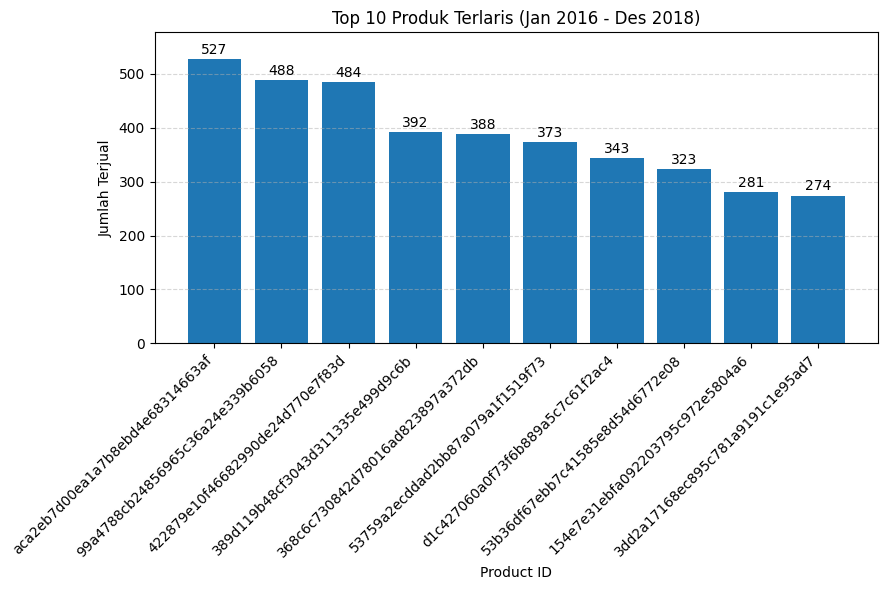

In [128]:
plt.figure(figsize=(9,6))

bars = plt.bar(top_products.index, top_products.values)

plt.title('Top 10 Produk Terlaris (Jan 2016 - Des 2018)')
plt.xlabel('Product ID')
plt.ylabel('Jumlah Terjual')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.ylim(0, max(top_products.values) + 50)

for i in range(len(top_products)):
    plt.text(i, top_products.values[i] + 10, int(top_products.values[i]), ha='center')

plt.tight_layout()
plt.show()

**Insight:**

- Hasil visualisasi menunjukkan bahwa produk dengan ID aca2eb7d00ea1a7b8ebd4e68314663af memiliki jumlah transaksi tertinggi, yaitu sebanyak 527 transaksi selama periode Januari 2016 hingga Desember 2018. Meskipun menjadi yang tertinggi, selisihnya dengan produk lain di peringkat atas tidak terlalu besar. Produk di posisi kedua dan ketiga masing masing mencatat 488 dan 484 transaksi, sehingga dapat dikatakan bahwa beberapa produk teratas memiliki performa yang relatif berdekatan.

- Jika dilihat lebih jauh, penurunan jumlah transaksi mulai terlihat secara bertahap pada peringkat berikutnya. Produk di posisi tengah hingga bawah dalam Top 10 memiliki jumlah transaksi di kisaran 300an, hingga akhirnya mencapai sekitar 274 transaksi pada peringkat terakhir. Pola ini menunjukkan adanya distribusi yang menurun secara konsisten, bukan perbedaan yang drastis antar produk.

Secara keseluruhan, tidak terdapat satu produk yang benar-benar mendominasi pasar secara signifikan. Sebaliknya, terdapat beberapa produk yang bersaing cukup ketat dalam hal jumlah penjualan, yang mengindikasikan bahwa preferensi pelanggan tersebar pada beberapa produk utama, bukan terfokus pada satu produk saja.

### Pertanyaan 2: Bagaimana tren jumlah transaksi bulanan berdasarkan jumlah order dari Januari 2016 hingga Desember 2018?

In [129]:
monthly_orders = all_df.groupby(
    all_df['order_purchase_timestamp'].dt.to_period('M')
)['order_id'].nunique()

monthly_orders.index = monthly_orders.index.to_timestamp()
monthly_orders.head()

,order_id
order_purchase_timestamp,
2016-09-01,3
2016-10-01,306
2016-12-01,1
2017-01-01,778
2017-02-01,1681


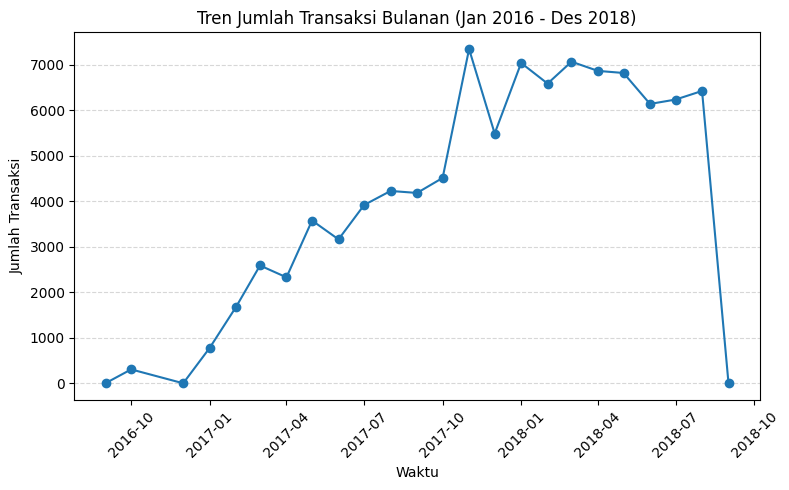

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker='o'
)

plt.title('Tren Jumlah Transaksi Bulanan (Jan 2016 - Des 2018)')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**

- Jumlah transaksi menunjukkan peningkatan yang cukup signifikan sepanjang tahun 2017. Pada awal tahun, transaksi masih berada di kisaran 700an hingga 2000an, kemudian meningkat secara bertahap hingga mencapai lebih dari 7000 transaksi pada akhir tahun.

- Puncak transaksi terjadi sekitar November 2017 dengan jumlah lebih dari 7000 transaksi, yang kemungkinan dipengaruhi oleh momen promosi besar atau peningkatan aktivitas belanja di akhir tahun.

- Memasuki tahun 2018, jumlah transaksi cenderung stabil pada kisaran 6000an hingga 7000an per bulan. Namun, terdapat anomali pada September 2018 di mana jumlah transaksi turun drastis mendekati nol, yang kemungkinan disebabkan oleh data yang tidak lengkap.

### Pertanyaan 3: Siapa saja pelanggan dengan jumlah transaksi terbanyak berdasarkan jumlah order pada periode Januari 2016 hingga Desember 2018, dan bagaimana perbandingan tingkat aktivitas transaksi di antara pelanggan tersebut?

In [131]:
customer_transactions = all_df.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False)

top_customers = customer_transactions.head(10)
top_customers

,order_id
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,15
3e43e6105506432c953e165fb2acf44c,9
ca77025e7201e3b30c44b472ff346268,7
6469f99c1f9dfae7733b25662e7f1782,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
12f5d6e1cbf93dafd9dcc19095df0b3d,6
47c1a3033b8b77b3ab6e109eb4d5fdf3,6
dc813062e0fc23409cd255f7f53c7074,6
35ecdf6858edc6427223b64804cf028e,5


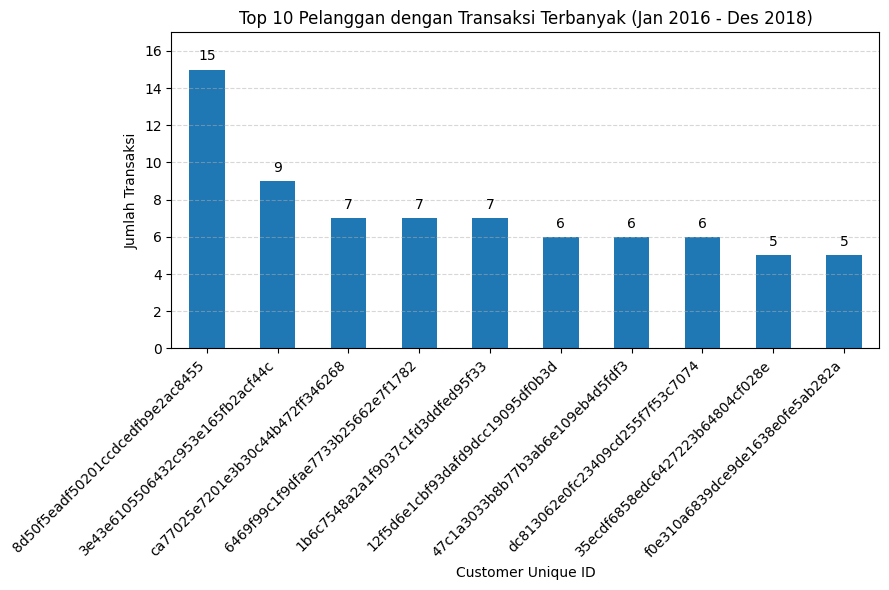

In [132]:
plt.figure(figsize=(9,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Pelanggan dengan Transaksi Terbanyak (Jan 2016 - Des 2018)')
plt.xlabel('Customer Unique ID')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=45, ha='right')

plt.ylim(0, max(top_customers.values) + 2)

for i, v in enumerate(top_customers.values):
    plt.text(i, v + 0.5, str(v), ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan visualisasi Top 10 pelanggan dengan jumlah transaksi terbanyak selama periode Januari 2016 hingga Desember 2018, terlihat bahwa pelanggan dengan ID 8d50f5eadf50201ccdcedfb9e2ac8455 memiliki jumlah transaksi tertinggi, yaitu sebanyak 15 transaksi. Jika dibandingkan dengan pelanggan di posisi kedua yang memiliki 9 transaksi, terdapat selisih yang cukup jelas, yang menunjukkan bahwa pelanggan teratas memiliki tingkat aktivitas yang lebih tinggi dibandingkan pelanggan lainnya.

- Namun, perbedaan tersebut tidak berlanjut secara signifikan pada posisi berikutnya. Sebagian besar pelanggan dalam daftar Top 10 hanya memiliki jumlah transaksi di kisaran 5 hingga 7 kali. Hal ini menunjukkan bahwa meskipun terdapat pelanggan yang lebih aktif, tingkat aktivitas transaksi antar pelanggan relatif tidak terlalu jauh berbeda setelah posisi pertama.

- Distribusi ini mengindikasikan bahwa tidak terdapat pelanggan yang benar  benar sangat dominan dalam hal jumlah transaksi. Bahkan pelanggan dengan aktivitas tertinggi pun hanya melakukan 15 transaksi selama periode yang cukup panjang, sehingga dapat dikatakan bahwa tingkat aktivitas pelanggan secara umum masih berada pada kategori moderat.

Secara keseluruhan, perbandingan ini menunjukkan bahwa aktivitas transaksi pelanggan cenderung tersebar dan tidak terpusat pada satu atau dua pelanggan saja, dengan perbedaan yang mulai mengecil setelah pelanggan dengan peringkat teratas.

### Pertanyaan 4: Kategori produk apa yang paling banyak terjual berdasarkan jumlah item yang dibeli oleh pelanggan selama periode dataset?

In [133]:
category_sales = all_df.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False)

top_categories = category_sales.head(10)
top_categories

,order_item_id
product_category_name,
cama_mesa_banho,11115
beleza_saude,9670
esporte_lazer,8641
moveis_decoracao,8334
informatica_acessorios,7827
utilidades_domesticas,6964
relogios_presentes,5991
telefonia,4545
ferramentas_jardim,4347


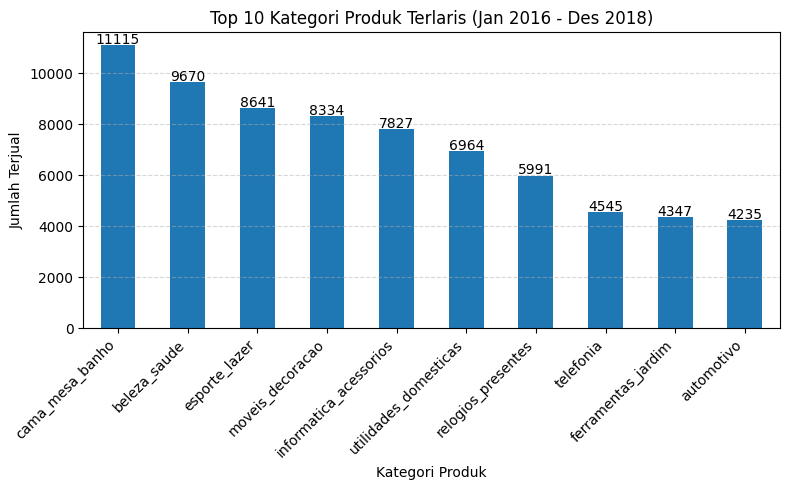

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

top_categories.plot(kind='bar')

plt.title('Top 10 Kategori Produk Terlaris (Jan 2016 - Des 2018)')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Terjual')

plt.xticks(rotation=45, ha='right')

plt.ylim(0, max(top_categories.values) + 500)

for i, v in enumerate(top_categories.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**

- Kategori cama_mesa_banho menjadi kategori dengan penjualan tertinggi, mencapai lebih dari 11 ribu item, dan memiliki jarak yang cukup jauh dibandingkan kategori lain di bawahnya. Hal ini menunjukkan bahwa kategori ini memiliki permintaan yang sangat kuat selama periode pengamatan.

- Kategori seperti beleza_saude, esporte_lazer, dan moveis_decoracao juga menunjukkan performa yang tinggi dengan penjualan di atas 8 ribu, yang menandakan adanya kelompok kategori unggulan yang secara konsisten diminati pelanggan.

- Setelah lima besar, terlihat adanya penurunan jumlah penjualan yang cukup jelas, di mana kategori seperti utilidades_domesticas dan *relogios_presentes* mulai berada di bawah 7 ribu hingga 6 ribu transaksi. Ini menunjukkan adanya perbedaan tingkat permintaan antar kelompok kategori.

- Pada kategori bagian bawah seperti telefonia, ferramentas_jardim, dan automotivo, jumlah penjualan relatif lebih rendah dan selisih antar kategori juga tidak terlalu jauh. Hal ini mengindikasikan bahwa pada kelompok ini tidak ada kategori yang benar-benar dominan.

Secara keseluruhan, distribusi penjualan antar kategori tidak merata dan cenderung terkonsentrasi pada beberapa kategori utama saja, sehingga kategori produk memiliki peran yang cukup besar dalam menentukan performa penjualan dibandingkan produk individual.

## Analisis Lanjutan (Opsional)

In [135]:
latest_date = all_df['order_purchase_timestamp'].max()

rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
})

rfm_df.columns = ['recency', 'frequency', 'monetary']

rfm_df.head()

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
0000f46a3911fa3c0805444483337064,541,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
0004aac84e0df4da2b147fca70cf8255,292,1,180.00


In [136]:
rfm_df.describe()

,recency,frequency,monetary
count,94108.000000,94108.000000,94108.00000
mean,241.882964,1.033674,142.51826
std,153.178338,0.208939,217.54602
min,0.000000,1.000000,0.85000
25%,118.000000,1.000000,47.90000
50%,222.000000,1.000000,89.80000
75%,351.000000,1.000000,155.80000
max,728.000000,15.000000,13440.00000


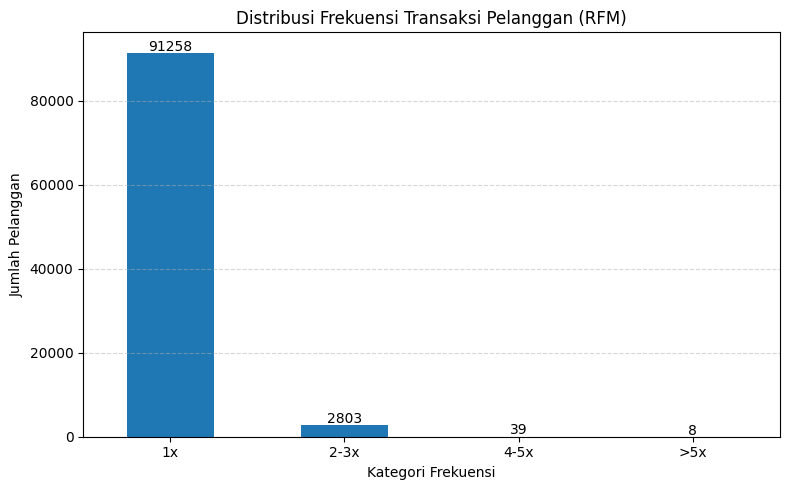

In [137]:
plt.figure(figsize=(8,5))

freq_group_dist = freq_group_dist.sort_index()

freq_group_dist.plot(kind='bar')

plt.title('Distribusi Frekuensi Transaksi Pelanggan (RFM)')
plt.xlabel('Kategori Frekuensi')
plt.ylabel('Jumlah Pelanggan')

plt.xticks(rotation=0)

plt.ylim(0, max(freq_group_dist.values) + 5000)

for i, v in enumerate(freq_group_dist.values):
    plt.text(i, v + 500, str(v), ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight Frequency:**

- Jumlah pelanggan yang hanya melakukan satu kali transaksi terlihat sangat dominan, yaitu sebanyak 91.258 pelanggan. Angka ini jauh melampaui kategori lainnya, yang menunjukkan bahwa sebagian besar pelanggan tidak melakukan pembelian ulang setelah transaksi pertama.

- Berbeda dengan kategori 1x, pelanggan yang melakukan transaksi sebanyak 2-3 kali hanya berjumlah 2.803, yang berarti terjadi penurunan yang sangat signifikan setelah transaksi pertama. Hal ini mengindikasikan adanya hambatan atau kurangnya dorongan bagi pelanggan untuk kembali bertransaksi.

- Pada frekuensi yang lebih tinggi, seperti 4-5 kali dan lebih dari 5 kali transaksi, jumlah pelanggan menjadi sangat kecil, masing masing hanya 39 dan 8 pelanggan. Ini menunjukkan bahwa pelanggan dengan tingkat aktivitas tinggi atau loyalitas kuat hampir tidak ditemukan dalam dataset ini.

- Jika dilihat dari pola penurunannya, distribusi frekuensi ini bersifat sangat tidak seimbang (skewed), di mana mayoritas pelanggan berhenti pada transaksi pertama dan hanya sebagian kecil yang melanjutkan ke transaksi berikutnya.

- Kondisi ini memberikan gambaran bahwa bisnis masih berfokus pada akuisisi pelanggan baru, namun belum optimal dalam mempertahankan pelanggan lama. Dengan demikian, terdapat peluang besar untuk meningkatkan strategi retensi pelanggan agar frekuensi transaksi dapat meningkat.

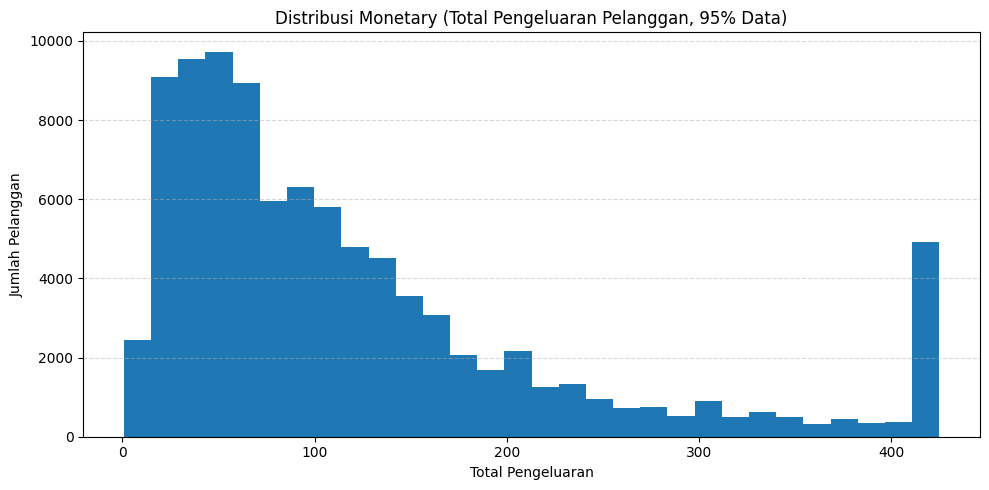

In [138]:
plt.figure(figsize=(10,5))

monetary_clipped = rfm_df['monetary'].clip(upper=rfm_df['monetary'].quantile(0.95))

monetary_clipped.plot(kind='hist', bins=30)

plt.title('Distribusi Monetary (Total Pengeluaran Pelanggan, 95% Data)')
plt.xlabel('Total Pengeluaran')
plt.ylabel('Jumlah Pelanggan')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight monetary:**

- Sebagian besar pelanggan memiliki total pengeluaran pada rentang rendah hingga menengah, yang terlihat dari tingginya konsentrasi batang histogram di bagian kiri grafik. Ini menunjukkan bahwa mayoritas pelanggan hanya berkontribusi dalam jumlah pengeluaran yang relatif kecil.

- Seiring meningkatnya nilai pengeluaran, jumlah pelanggan mengalami penurunan secara bertahap. Pola ini memperlihatkan bahwa semakin tinggi total pengeluaran, semakin sedikit jumlah pelanggan yang berada pada kategori tersebut.

- Distribusi data terlihat tidak simetris dan cenderung memanjang ke kanan, yang menandakan adanya sejumlah kecil pelanggan dengan pengeluaran yang jauh lebih tinggi dibandingkan pelanggan lainnya.

- Meskipun jumlahnya sedikit, pelanggan dengan pengeluaran tinggi ini memiliki potensi kontribusi yang besar terhadap total pendapatan, sehingga keberadaan mereka menjadi penting dalam strategi bisnis.

- Dengan adanya pembatasan hingga 95% data, pola distribusi utama menjadi lebih jelas terlihat tanpa terlalu dipengaruhi oleh nilai ekstrem, sehingga analisis lebih merepresentasikan kondisi mayoritas pelanggan.

- Jika dikaitkan dengan hasil analisis frekuensi sebelumnya, terlihat bahwa pelanggan dengan nilai pengeluaran tinggi kemungkinan berasal dari kelompok pelanggan yang lebih aktif dalam bertransaksi, meskipun jumlahnya sangat terbatas.

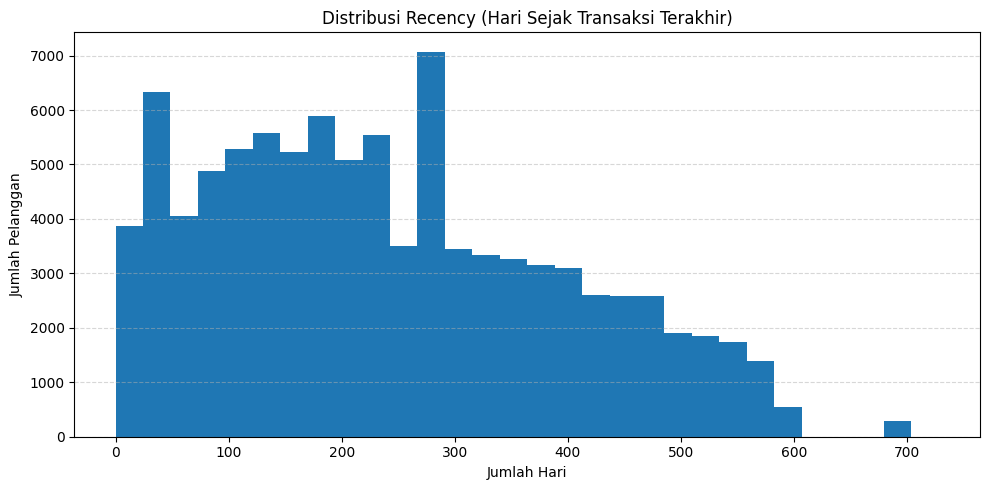

In [139]:
plt.figure(figsize=(10,5))

rfm_df['recency'].plot(kind='hist', bins=30)

plt.title('Distribusi Recency (Hari Sejak Transaksi Terakhir)')
plt.xlabel('Jumlah Hari')
plt.ylabel('Jumlah Pelanggan')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight Recency:**

- Distribusi recency menunjukkan bahwa sebagian besar pelanggan berada pada rentang sekitar 50 hingga 300 hari sejak transaksi terakhir. Hal ini terlihat dari konsentrasi batang histogram yang cukup padat pada rentang tersebut, yang mengindikasikan bahwa banyak pelanggan sudah cukup lama tidak melakukan transaksi.

- Seiring bertambahnya jumlah hari, jumlah pelanggan cenderung menurun secara bertahap. Pola ini menunjukkan bahwa semakin lama pelanggan tidak bertransaksi, semakin sedikit jumlah pelanggan dalam kategori tersebut, meskipun tetap terdapat sejumlah pelanggan yang memiliki recency sangat tinggi.

- Terdapat pelanggan dengan nilai recency yang cukup besar, bahkan mendekati 600 hingga 700 hari. Hal ini mengindikasikan adanya kelompok pelanggan yang sudah lama tidak kembali melakukan transaksi, sehingga dapat dikategorikan sebagai pelanggan tidak aktif atau berisiko churn.

- Di sisi lain, jumlah pelanggan dengan recency rendah misalnya di bawah 50 hari relatif lebih sedikit dibandingkan kelompok menengah. Ini menunjukkan bahwa hanya sebagian kecil pelanggan yang baru saja melakukan transaksi dalam waktu dekat.

- Jika dikaitkan dengan hasil analisis frequency sebelumnya, kondisi ini memperkuat bahwa tidak hanya frekuensi transaksi yang rendah, tetapi juga banyak pelanggan yang tidak kembali dalam waktu dekat setelah transaksi terakhir.

- Secara keseluruhan, distribusi ini menunjukkan bahwa tingkat keterlibatan pelanggan cenderung menurun seiring waktu, sehingga diperlukan strategi untuk mengaktifkan kembali pelanggan yang sudah lama tidak bertransaksi.

## Conclusion

**Conclusion:**

Berdasarkan hasil analisis yang telah dilakukan, setiap pertanyaan yang diajukan memberikan gambaran yang saling melengkapi terkait performa penjualan dan perilaku pelanggan pada dataset e-commerce selama periode Januari 2016 hingga Desember 2018.

Pada pertanyaan pertama yang berfokus pada produk dengan penjualan tertinggi, ditemukan bahwa hanya beberapa produk yang memiliki jumlah penjualan yang lebih tinggi dibandingkan produk lainnya. Meskipun terdapat produk yang mencapai lebih dari 500 transaksi, sebagian besar produk lainnya berada pada rentang yang tidak terlalu jauh berbeda. Hal ini menunjukkan bahwa penjualan pada tingkat produk cenderung tersebar dan tidak terlalu didominasi oleh satu produk saja.

Pada pertanyaan kedua yang membahas tren jumlah transaksi berdasarkan waktu, terlihat adanya peningkatan yang cukup signifikan dari tahun 2016 menuju tahun 2017, yang kemudian diikuti dengan kondisi yang relatif stabil pada tahun 2018. Pola ini menunjukkan adanya fase pertumbuhan awal yang kemudian mencapai titik stabil, meskipun tetap terdapat fluktuasi bulanan yang kemungkinan dipengaruhi oleh momen tertentu.

Selanjutnya, pada pertanyaan ketiga terkait pelanggan dengan jumlah transaksi terbanyak, terlihat bahwa pelanggan dengan aktivitas tertinggi hanya melakukan 15 transaksi. Sementara itu, sebagian besar pelanggan lainnya berada pada kisaran 5 hingga 7 transaksi. Hal ini menunjukkan bahwa tidak terdapat pelanggan yang sangat dominan dalam aktivitas transaksi, dan tingkat aktivitas pelanggan secara umum masih tergolong moderat.

Pada pertanyaan keempat yang berfokus pada kategori produk, ditemukan bahwa kategori seperti cama_mesa_banho, beleza_saude, dan esporte_lazer memiliki jumlah penjualan yang jauh lebih tinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa kategori produk memiliki pengaruh yang cukup besar terhadap performa penjualan, dengan beberapa kategori menjadi kontributor utama.

Jika dikaitkan dengan analisis lanjutan menggunakan metode RFM, hasil yang diperoleh semakin memperjelas pola perilaku pelanggan. Pada aspek frequency, sebagian besar pelanggan hanya melakukan satu kali transaksi, yang menunjukkan rendahnya tingkat pembelian ulang. Pada aspek monetary, mayoritas pelanggan memiliki total pengeluaran yang relatif rendah, sementara hanya sebagian kecil pelanggan yang memberikan kontribusi besar terhadap pendapatan. Pada aspek recency, banyak pelanggan yang sudah cukup lama tidak melakukan transaksi, yang mengindikasikan adanya potensi pelanggan tidak aktif.

Secara keseluruhan, hasil analisis menunjukkan bahwa meskipun terdapat pertumbuhan dan kategori produk yang kuat, bisnis masih menghadapi tantangan dalam mempertahankan pelanggan. Mayoritas pelanggan tidak melakukan pembelian ulang dan memiliki tingkat keterlibatan yang rendah.

Oleh karena itu, strategi yang dapat dipertimbangkan adalah meningkatkan retensi pelanggan melalui program loyalitas, seperti pemberian voucher diskon untuk pembelian kedua, sistem poin reward berdasarkan jumlah transaksi atau nilai pembelian, serta penawaran khusus personalized promotion kepada pelanggan yang sudah lama tidak bertransaksi. Selain itu, pengiriman notifikasi atau email reminder kepada pelanggan dengan recency tinggi juga dapat membantu mendorong pelanggan untuk kembali melakukan transaksi.

Di sisi lain, bisnis juga dapat memaksimalkan potensi dari kategori produk yang sudah terbukti memiliki performa tinggi dengan memberikan bundling produk atau promosi khusus pada kategori tersebut, sehingga dapat meningkatkan nilai transaksi sekaligus menarik minat pelanggan untuk melakukan pembelian ulang.

In [140]:
# Melakukan sampling sebesar 60% dari total data
# Tujuan: mengurangi ukuran file agar dapat diupload ke GitHub (<25MB)
# tanpa menghilangkan pola utama dalam data

sample_df = all_df.sample(frac=0.6, random_state=42)
sample_df.to_csv('main_data.csv', index=False)